# Sales Forcasting System Project

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv('data.csv')

In [3]:
df.to_csv("data.csv", index=False)

In [4]:
df.head()

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,Low
2,5 Series,2022,North America,Blue,Petrol,Automatic,4.5,10991,113265,6994,Low
3,X3,2024,Middle East,Blue,Petrol,Automatic,1.7,27255,60971,4047,Low
4,7 Series,2020,South America,Black,Diesel,Manual,2.1,122131,49898,3080,Low


In [5]:
df.shape

(50000, 11)

In [6]:
df.tail()


,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume,Sales_Classification
49995,i3,2014,Asia,Red,Hybrid,Manual,4.6,151030,42932,8182,High
49996,i3,2023,Middle East,Silver,Electric,Manual,4.2,147396,48714,9816,High
49997,5 Series,2010,Middle East,Red,Petrol,Automatic,4.5,174939,46126,8280,High
49998,i3,2020,Asia,White,Electric,Automatic,3.8,3379,58566,9486,High
49999,X1,2020,North America,Blue,Diesel,Manual,3.3,171003,77492,1764,Low


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 50000 non-null  object 
 1   Year                  50000 non-null  int64  
 2   Region                50000 non-null  object 
 3   Color                 50000 non-null  object 
 4   Fuel_Type             50000 non-null  object 
 5   Transmission          50000 non-null  object 
 6   Engine_Size_L         50000 non-null  float64
 7   Mileage_KM            50000 non-null  int64  
 8   Price_USD             50000 non-null  int64  
 9   Sales_Volume          50000 non-null  int64  
 10  Sales_Classification  50000 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 4.2+ MB


In [8]:
df.describe()

,Year,Engine_Size_L,Mileage_KM,Price_USD,Sales_Volume
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2017.015700,3.247180,100307.203140,75034.600900,5067.514680
std,4.324459,1.009078,57941.509344,25998.248882,2856.767125
min,2010.000000,1.500000,3.000000,30000.000000,100.000000
25%,2013.000000,2.400000,50178.000000,52434.750000,2588.000000
50%,2017.000000,3.200000,100388.500000,75011.500000,5087.000000
75%,2021.000000,4.100000,150630.250000,97628.250000,7537.250000
max,2024.000000,5.000000,199996.000000,119998.000000,9999.000000


In [9]:
X = df.drop(columns=['Sales_Volume'])
y = df['Sales_Volume']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((40000, 10), (10000, 10))

In [11]:
X_train.head(3)

,Model,Year,Region,Color,Fuel_Type,Transmission,Engine_Size_L,Mileage_KM,Price_USD,Sales_Classification
39087,X6,2018,Middle East,Grey,Hybrid,Manual,1.8,76510,108720,High
30893,X5,2023,South America,Grey,Diesel,Automatic,3.4,93901,106589,Low
45278,M5,2010,Middle East,Silver,Diesel,Manual,4.3,166293,67868,Low


In [12]:
y_train.head(3)

39087    7311
30893    6087
45278    3466
Name: Sales_Volume, dtype: int64

In [13]:
X_train_c = X_train.copy()


In [14]:
X_train_c.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40000 entries, 39087 to 15795
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Model                 40000 non-null  object 
 1   Year                  40000 non-null  int64  
 2   Region                40000 non-null  object 
 3   Color                 40000 non-null  object 
 4   Fuel_Type             40000 non-null  object 
 5   Transmission          40000 non-null  object 
 6   Engine_Size_L         40000 non-null  float64
 7   Mileage_KM            40000 non-null  int64  
 8   Price_USD             40000 non-null  int64  
 9   Sales_Classification  40000 non-null  object 
dtypes: float64(1), int64(3), object(6)
memory usage: 3.4+ MB


In [15]:
X_train_c.isnull().sum()

Model                   0
Year                    0
Region                  0
Color                   0
Fuel_Type               0
Transmission            0
Engine_Size_L           0
Mileage_KM              0
Price_USD               0
Sales_Classification    0
dtype: int64

In [16]:
num_data = X_train_c.select_dtypes(exclude=['object'])
num_data.head()

,Year,Engine_Size_L,Mileage_KM,Price_USD
39087,2018,1.8,76510,108720
30893,2023,3.4,93901,106589
45278,2010,4.3,166293,67868
16398,2016,2.9,143430,51048
13653,2019,4.0,78259,64615


In [17]:
num_data.describe()

,Year,Engine_Size_L,Mileage_KM,Price_USD
count,40000.000000,40000.000000,40000.000000,40000.00000
mean,2017.028825,3.247212,100223.862650,75060.54400
std,4.319550,1.010707,57950.236413,25993.34112
min,2010.000000,1.500000,3.000000,30000.00000
25%,2013.000000,2.400000,49939.500000,52547.00000
50%,2017.000000,3.300000,100358.000000,74974.00000
75%,2021.000000,4.100000,150576.500000,97624.75000
max,2024.000000,5.000000,199996.000000,119997.00000


In [18]:
num_data.isnull().sum()

Year             0
Engine_Size_L    0
Mileage_KM       0
Price_USD        0
dtype: int64

In [19]:
df = df.drop_duplicates()

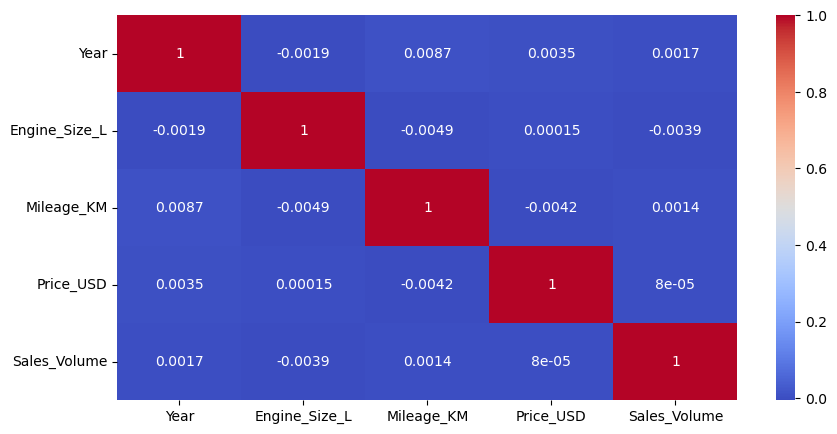

In [20]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [21]:
for col in df.columns:
    print(f"'{col}'")

'Model'
'Year'
'Region'
'Color'
'Fuel_Type'
'Transmission'
'Engine_Size_L'
'Mileage_KM'
'Price_USD'
'Sales_Volume'
'Sales_Classification'


In [22]:
X = df.drop(['Sales_Volume'], axis=1)
y = df['Sales_Volume']

In [23]:
X = pd.get_dummies(X, drop_first=True)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
y_pred = model.predict(X_test)

In [27]:
from sklearn.metrics import mean_absolute_error, r2_score

In [28]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1427.172217104005
R2 Score: 0.6352234209208196


In [29]:
X = df.drop(['Sales_Classification'], axis=1)
y = df['Sales_Classification']

In [30]:
X = pd.get_dummies(X, drop_first=True)

In [31]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [33]:
from sklearn.metrics import accuracy_score, classification_report

In [34]:
y_pred = model.predict(X_test)

In [35]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9988
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      3032
         Low       1.00      1.00      1.00      6968

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000



In [36]:
from sklearn.preprocessing import StandardScaler

In [37]:
scaler = StandardScaler()

In [38]:
train_sc = scaler.fit_transform(X_train)
test_sc = scaler.transform(X_test)

In [39]:
from sklearn.svm import SVC

In [40]:
model = SVC(kernel='rbf',C=1.0,gamma='scale')

In [41]:
model.fit(train_sc , y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [42]:
pred = model.predict(test_sc)

In [43]:
from sklearn.metrics import classification_report , accuracy_score

In [44]:
print('Score' , accuracy_score(y_test , pred))

Score 0.99


In [45]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

        High       0.98      0.99      0.98      3032
         Low       0.99      0.99      0.99      6968

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [46]:
X = pd.get_dummies(X, drop_first=True)


In [47]:
from sklearn.tree import DecisionTreeRegressor

In [48]:
from sklearn.tree import plot_tree

In [49]:
X = df.drop(['Price_USD'], axis=1)
y = df['Price_USD']

In [50]:
X = pd.get_dummies(X, drop_first=True)

In [51]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

In [52]:
clf = DecisionTreeRegressor(max_depth=3)
clf.fit(X, y)


,criterion,'squared_error'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


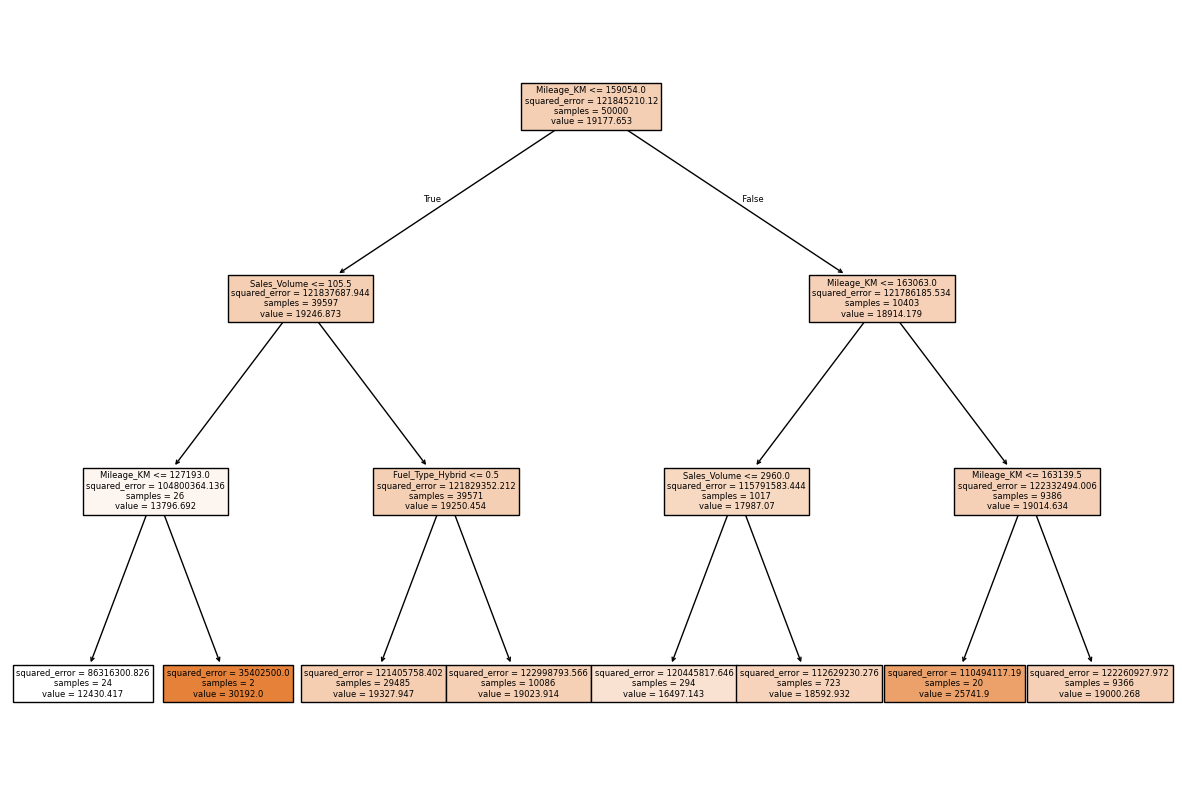

In [53]:
plt.figure(figsize=(15,10))
plot_tree(clf, feature_names=list(X.columns), filled=True)
plt.show()

In [54]:
X = df.drop(['Sales_Classification','Sales_Volume'], axis=1)
y = df['Sales_Classification']

In [55]:
X = pd.get_dummies(X, drop_first=True)

In [56]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)

In [57]:
from sklearn.tree import DecisionTreeClassifier , plot_tree

In [58]:
clf = DecisionTreeClassifier()

In [59]:
clf.fit(X_train , y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [60]:
clf.score(X_test , y_test)

0.5745

In [61]:
pred = clf.predict(X_test)

In [62]:
from sklearn.metrics import classification_report

In [63]:
print(classification_report(y_test , pred))

              precision    recall  f1-score   support

        High       0.31      0.33      0.32      3032
         Low       0.70      0.68      0.69      6968

    accuracy                           0.57     10000
   macro avg       0.50      0.50      0.50     10000
weighted avg       0.58      0.57      0.58     10000



In [64]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [65]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=15)
clf.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [66]:
label = y.map({0 : 'yes' , 1 : 'no'}).unique()

In [67]:
class_names=clf.classes_

In [68]:
label

array([nan], dtype=object)

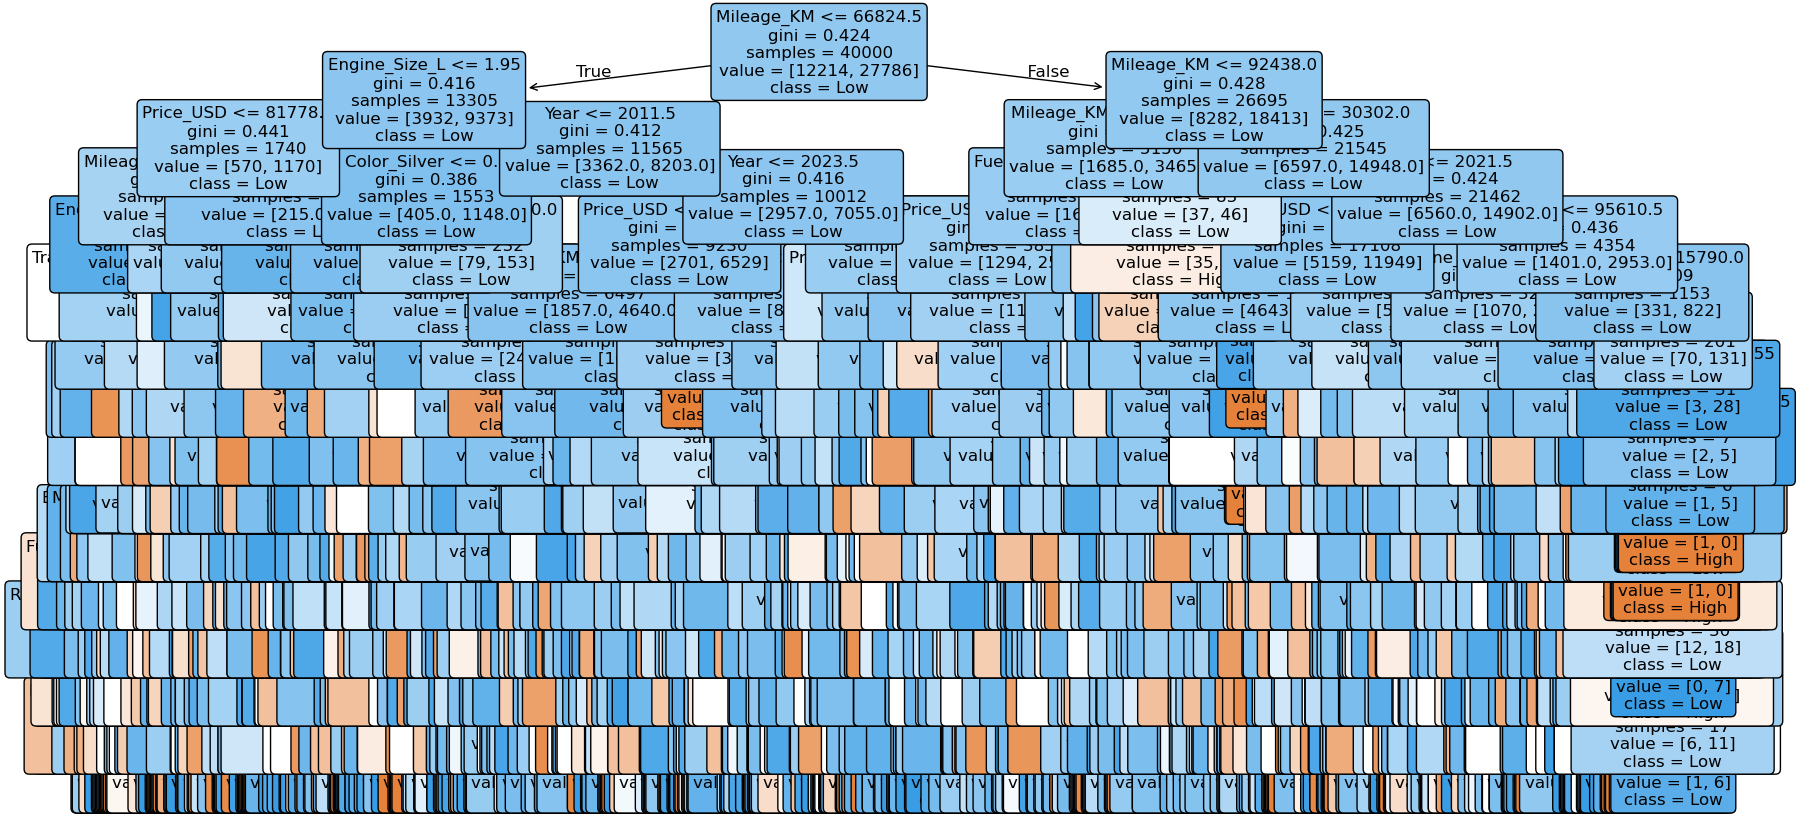

In [69]:
plt.figure(figsize = (20,10))
plot_tree(clf , feature_names= list(X.columns) , class_names=clf.classes_ , rounded=True , filled=True , fontsize=12)
plt.show()

In [70]:
cat_cols = X.select_dtypes(include = 'object').columns.to_list()
num_cols = X.select_dtypes(include = ['int64' , 'float64']).columns.to_list()

In [71]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [72]:
cat_cols = X.select_dtypes(include='object').columns

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [74]:
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

In [75]:
preprocessor = ColumnTransformer([
    ('scaling' , StandardScaler() , num_cols),
    ('encoder' , OneHotEncoder(handle_unknown='ignore') , cat_cols)
] , remainder = 'passthrough')

In [76]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

In [77]:
clf = Pipeline([
    ('pre' , preprocessor),
    ('model' , RandomForestClassifier(random_state=42))
])

In [78]:
clf.fit(X_train , y_train)

,steps,"[('pre', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaling', ...), ('encoder', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [79]:
clf.score(X_test , y_test)

0.6839

In [80]:
pred = clf.predict(X_test)

In [81]:
from sklearn.metrics import classification_report

In [82]:
print(classification_report(y_test , pred))

              precision    recall  f1-score   support

        High       0.25      0.02      0.04      3049
         Low       0.69      0.98      0.81      6951

    accuracy                           0.68     10000
   macro avg       0.47      0.50      0.42     10000
weighted avg       0.56      0.68      0.57     10000



In [83]:
import numpy as np

print("Predictions:", np.unique(pred, return_counts=True))

Predictions: (array(['High', 'Low'], dtype=object), array([ 228, 9772]))


In [84]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

        High       0.25      0.02      0.04      3049
         Low       0.69      0.98      0.81      6951

    accuracy                           0.68     10000
   macro avg       0.47      0.50      0.42     10000
weighted avg       0.56      0.68      0.57     10000



In [85]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, pred))

[[  58 2991]
 [ 170 6781]]


In [86]:
print(confusion_matrix(y_test, pred, labels=['Low', 'High']))

[[6781  170]
 [2991   58]]


In [87]:
import seaborn as sns
import matplotlib.pyplot as plt

In [88]:
cm = confusion_matrix(y_test, pred)

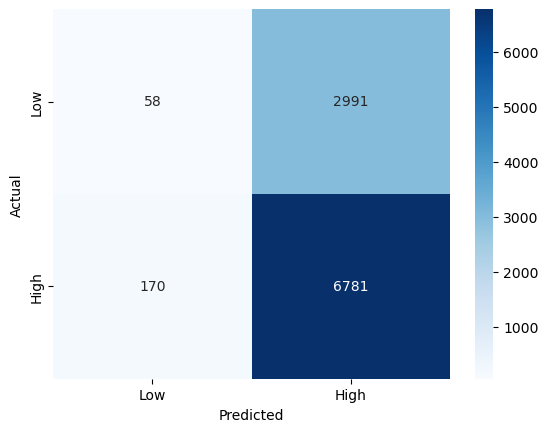

In [89]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low','High'],
            yticklabels=['Low','High'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [90]:
model = RandomForestClassifier(random_state=42)

In [91]:
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [92]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(clf, X, y, cv=5)
print("CV Accuracy:", scores.mean())

CV Accuracy: 0.68622


In [93]:
import pickle

pickle.dump(model, open('model_rf.pkl', 'wb'))
pickle.dump(X.columns, open('columns.pkl', 'wb'))

In [94]:
import pickle
pickle.dump(clf, open("model.pkl", "wb"))

In [95]:
X_test.to_csv("X_test.csv", index=False)
y_test.to_csv("y_test.csv", index=False)